# Telecom customer churn analysis

## Introduction

Customer churn, also known as customer attrition or customer defections refers to a company losing customers. Telecommunication service companies often use customer attrition rates as one of their key business metrics because the cost of acquiring a new customer far exceeds that of retaining an existing customer.

In this case study, you will analyze a customer churn dataset for a telecommunications company that provides phone and internet services in California.

### Questions to ask

- How many customers joined the company during the last quarter? How many customers churned?
- What is the customer profile for a customer that churned, joined, and stayed? Are they different?
- What seem to be the key drivers of customer churn?
- Is the company losing high value customers? If so, how can they retain them?
- Can you build a prediction model that our client can use to identify customers at risk of churning?

[Customer Attrition - Wikipedia](https://en.wikipedia.org/wiki/Customer_attrition)

In [1]:
import pandas as pd
import numpy as np

In [2]:
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

print(f'pandas version: {pd.__version__}')
print(f'plotly version: {plotly.__version__}')

pandas version: 3.0.6
plotly version: 7.1.0


In [3]:
pio.templates['sans_serif'] = go.layout.Template(dict(
    layout=go.Layout(
        font_family='Helvetica, Inter, Arial, sans-serif',
    ),
))

pio.templates.default = 'simple_white+sans_serif'

# Churned customers are the accent color throughout; everything else is blue or gray
COLOR_CHURNED = '#DC2626'
COLOR_JOINED = '#2563EB'
COLOR_STAYED = '#9CA3AF'
COLOR_LIGHT_GRAY = '#D1D5DB'

In [4]:
import glob

glob.glob('*.csv')

['telecom_zipcode_population.csv', 'telecom_customer_churn.csv']

In [5]:
pd.set_option('display.max_columns', 100)

## About the dataset

The dataset contains churn data for a Telecommunications company that provides phone and internet services to 7,043 customers in California, and includes details about customer demographics, location, services, and current status.

Source: [Maven Analytics Data Playground](https://www.mavenanalytics.io/data-playground)

### Data dictionary

The table below describes each column in the `'telecom_customer_churn.csv'` file.

| Field                             | Description                                                                                                                                                                                                                  |
|-----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| CustomerID                        | A unique ID that identifies each customer                                                                                                                                                                                    |
| Gender                            | The customer's gender: Male, Female                                                                                                                                                                                          |
| Age                               | The customer's current age, in years, at the time the fiscal quarter   ended (Q2 2022)                                                                                                                                       |
| Married                           | Indicates if the customer is married: Yes, No                                                                                                                                                                                |
| Number of Dependents              | Indicates the number of dependents that live with the customer   (dependents could be children, parents, grandparents, etc.)                                                                                                 |
| City                              | The city of the customer's primary residence in California                                                                                                                                                                   |
| Zip Code                          | The zip code of the customer's primary residence                                                                                                                                                                             |
| Latitude                          | The latitude of the customer's primary residence                                                                                                                                                                             |
| Longitude                         | The longitude of the customer's primary residence                                                                                                                                                                            |
| Number of Referrals               | Indicates the number of times the customer has referred a friend or   family member to this company to date                                                                                                                  |
| Tenure in Months                  | Indicates the total amount of months that the customer has been with the   company by the end of the quarter specified above                                                                                                 |
| Offer                             | Identifies the last marketing offer that the customer accepted: None,   Offer A, Offer B, Offer C, Offer D, Offer E                                                                                                          |
| Phone Service                     | Indicates if the customer subscribes to home phone service with the   company: Yes, No                                                                                                                                       |
| Avg Monthly Long Distance Charges | Indicates the customer's average long distance charges, calculated to the   end of the quarter specified above (if the customer is not subscribed to home   phone service, this will be 0)                                   |
| Multiple Lines                    | Indicates if the customer subscribes to multiple telephone lines with the   company: Yes, No (if the customer is not subscribed to home phone service,   this will be No)                                                    |
| Internet Service                  | Indicates if the customer subscribes to Internet service with the   company: Yes, No                                                                                                                                         |
| Internet Type                     | Indicates the customer's type of internet connection: DSL, Fiber Optic,   Cable (if the customer is not subscribed to internet service, this will be   None)                                                                 |
| Avg Monthly GB Download           | Indicates the customer's average download volume in gigabytes, calculated   to the end of the quarter specified above (if the customer is not subscribed   to internet service, this will be 0)                              |
| Online Security                   | Indicates if the customer subscribes to an additional online security   service provided by the company: Yes, No (if the customer is not subscribed   to internet service, this will be No)                                  |
| Online Backup                     | Indicates if the customer subscribes to an additional online backup   service provided by the company: Yes, No (if the customer is not subscribed   to internet service, this will be No)                                    |
| Device Protection Plan            | Indicates if the customer subscribes to an additional device protection   plan for their Internet equipment provided by the company: Yes, No (if the   customer is not subscribed to internet service, this will be No)      |
| Premium Tech Support              | Indicates if the customer subscribes to an additional technical support   plan from the company with reduced wait times: Yes, No (if the customer is   not subscribed to internet service, this will be No)                  |
| Streaming TV                      | Indicates if the customer uses their Internet service to stream   television programing from a third party provider at no additional fee: Yes,   No (if the customer is not subscribed to internet service, this will be No) |
| Streaming Movies                  | Indicates if the customer uses their Internet service to stream movies   from a third party provider at no additional fee: Yes, No (if the customer is   not subscribed to internet service, this will be No)                |
| Streaming Music                   | Indicates if the customer uses their Internet service to stream music   from a third party provider at no additional fee: Yes, No (if the customer is   not subscribed to internet service, this will be No)                 |
| Unlimited Data                    | Indicates if the customer has paid an additional monthly fee to have   unlimited data downloads/uploads: Yes, No (if the customer is not subscribed   to internet service, this will be No)                                  |
| Contract                          | Indicates the customer's current contract type: Month-to-Month, One Year,   Two Year                                                                                                                                         |
| Paperless Billing                 | Indicates if the customer has chosen paperless billing: Yes, No                                                                                                                                                              |
| Payment Method                    | Indicates how the customer pays their bill: Bank Withdrawal, Credit Card,   Mailed Check                                                                                                                                     |
| Monthly Charge                    | Indicates the customer's current total monthly charge for all their   services from the company                                                                                                                              |
| Total Charges                     | Indicates the customer's total charges, calculated to the end of the   quarter specified above                                                                                                                               |
| Total Refunds                     | Indicates the customer's total refunds, calculated to the end of the   quarter specified above                                                                                                                               |
| Total Extra Data Charges          | Indicates the customer's total charges for extra data downloads above   those specified in their plan, by the end of the quarter specified above                                                                             |
| Total Long Distance Charges       | Indicates the customer's total charges for long distance above those   specified in their plan, by the end of the quarter specified above                                                                                    |
| Total Revenue                     | Indicates the company's total revenue from this customer, calculated to   the end of the quarter specified above (Total Charges - Total Refunds +   Total Extra Data Charges + Total Long Distance Charges)                 |
| Customer Status                   | Indicates the status of the customer at the end of the quarter: Churned,   Stayed, or Joined                                                                                                                                 |
| Churn Category                    | A high-level category for the customer's reason for churning, which is   asked when they leave the company: Attitude, Competitor, Dissatisfaction,   Other, Price (directly related to Churn Reason)                         |
| Churn Reason                      | A customer's specific reason for leaving the company, which is asked when   they leave the company (directly related to Churn Category)                                                                                      |

In [6]:
df_churn = pd.read_csv('telecom_customer_churn.csv')
df_churn.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [7]:
df_churn['Customer Status'].value_counts()

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [8]:
df_churn['Churn Reason'].value_counts()

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Long distance charges                         64
Service dissatisfaction                       63
Moved                                         46
Extra data charges                            39
Limited range of services                     37
Poor expertise of online support              31
Lack of affordable download/upload speed      30
Lack of self-service on Website               29
Poor expertise of phone support               12
Deceased                                       6
Name: c

In [9]:
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   str    
 12  Pho

## Data preparation

Several columns use blanks to mean "not applicable" rather than "unknown":

- `Offer` is blank when the customer never accepted a marketing offer.
- `Internet Type`, `Avg Monthly GB Download`, and the eight internet add-on columns (`Online Security`, `Premium Tech Support`, ...) are blank for the 1,526 customers without internet service.
- `Multiple Lines` and `Avg Monthly Long Distance Charges` are blank for the 682 customers without phone service.
- `Churn Category` and `Churn Reason` only exist for churned customers.

We replace these blanks with explicit labels (`'None'`, `'No internet'`, `'No phone'`) or 0 and add a binary `Churned` flag. We work on a copy (`df`) so that `df_churn` stays exactly as loaded.

In [10]:
df = df_churn.copy()

internet_addons = [
    'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
    'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data',
]

df['Offer'] = df['Offer'].fillna('None')
df['Internet Type'] = df['Internet Type'].fillna('No internet')
df[internet_addons] = df[internet_addons].fillna('No internet')
df['Multiple Lines'] = df['Multiple Lines'].fillna('No phone')
df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)

# 1 = churned during the quarter, 0 = still a customer at the end of the quarter (Stayed or Joined)
df['Churned'] = (df['Customer Status'] == 'Churned').astype(int)

# Only the churn category/reason columns should still have missing values
df.isna().sum().loc[lambda s: s > 0]

Churn Category    5174
Churn Reason      5174
dtype: int64

### What does "Joined" mean?

`Customer Status` has three values. Looking at tenure by status shows how they are defined.

In [11]:
df.groupby('Customer Status').agg(
    customers=('Customer ID', 'count'),
    min_tenure=('Tenure in Months', 'min'),
    median_tenure=('Tenure in Months', 'median'),
    max_tenure=('Tenure in Months', 'max'),
)

,customers,min_tenure,median_tenure,max_tenure
Customer Status,,,,
Churned,1869,1,10.0,72
Joined,454,1,1.0,3
Stayed,4720,4,42.0,72


- **Joined** customers all have 1–3 months of tenure: they signed up during the quarter and were still customers at its end.
- **Stayed** customers all have at least 4 months of tenure: they were customers before the quarter began and did not leave.
- **Churned** customers span the full 1–72 month range. Their tenure appears to be measured up to the date they left, so a churned customer with a short tenure may have joined during this quarter or the previous one.

This matters later: a customer with 3 months or less of tenure who did *not* churn is, by definition, labelled Joined rather than Stayed.

In [12]:
print(f"Customers with a negative monthly charge: {(df['Monthly Charge'] < 0).sum()}")

df.query('`Monthly Charge` < 0')[['Monthly Charge', 'Tenure in Months', 'Total Charges']].describe().round(2)

Customers with a negative monthly charge: 120


,Monthly Charge,Tenure in Months,Total Charges
count,120.00,120.00,120.00
mean,-5.42,29.77,2028.86
std,2.89,24.64,2120.44
min,-10.00,1.00,19.40
25%,-8.00,7.00,343.02
50%,-5.00,22.50,1325.98
75%,-3.00,54.00,3239.51
max,-1.00,72.00,7942.15


**Data quality note:** 120 customers have a *negative* monthly charge (between -\$10 and -\$1) even though their total charges are positive. This is most likely a data entry error or an unexplained credit. They are few enough (under 2% of customers) that we keep them as they are; they all land in the lowest monthly-charge group used later.

## How many customers joined and churned last quarter?

In [13]:
df_status = df.groupby('Customer Status', as_index=False).agg({
    'Customer ID': 'count',
    'Monthly Charge': 'sum',
}).rename(columns={
    'Customer ID': 'customers',
    'Monthly Charge': 'total_monthly_charges',
})

df_status

,Customer Status,customers,total_monthly_charges
0,Churned,1869,137086.65
1,Joined,454,19420.30
2,Stayed,4720,291400.60


In [14]:
n = df_status.set_index('Customer Status')['customers']
mrr = df_status.set_index('Customer Status')['total_monthly_charges']

start_of_quarter = n['Stayed'] + n['Churned']
end_of_quarter = n['Stayed'] + n['Joined']
net_change = end_of_quarter - start_of_quarter

print(f'Customers at start of quarter (Stayed + Churned): {start_of_quarter:,}')
print(f'Customers at end of quarter (Stayed + Joined):    {end_of_quarter:,}')
print(f'Net change: {net_change:,} ({net_change / start_of_quarter:.1%})')
print(f"Churned customers per new customer: {n['Churned'] / n['Joined']:.1f}")
print(f"Quarterly churn rate (churned / start of quarter): {n['Churned'] / start_of_quarter:.1%}")
print()
print(f"Monthly charges lost with churned customers: ${mrr['Churned']:,.0f}")
print(f"Monthly charges added by new customers:      ${mrr['Joined']:,.0f}")
print(f"Share of start-of-quarter monthly charges lost: {mrr['Churned'] / (mrr['Stayed'] + mrr['Churned']):.1%}")
print(f"Lost monthly charges, annualized: ${mrr['Churned'] * 12:,.0f}")
print()
short_tenure_churners = df.query('Churned == 1 and `Tenure in Months` <= 3').shape[0]
print(f'Churned customers with a tenure of 3 months or less: {short_tenure_churners}')

Customers at start of quarter (Stayed + Churned): 6,589
Customers at end of quarter (Stayed + Joined):    5,174
Net change: -1,415 (-21.5%)
Churned customers per new customer: 4.1
Quarterly churn rate (churned / start of quarter): 28.4%

Monthly charges lost with churned customers: $137,087
Monthly charges added by new customers:      $19,420
Share of start-of-quarter monthly charges lost: 32.0%
Lost monthly charges, annualized: $1,645,040

Churned customers with a tenure of 3 months or less: 597


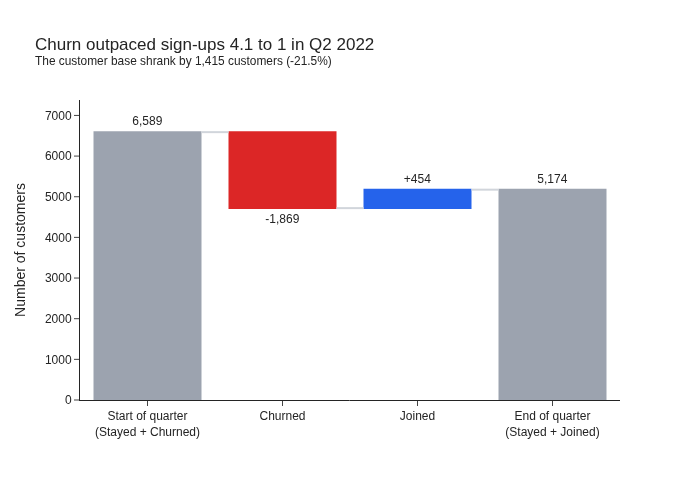

In [15]:
fig = go.Figure(go.Waterfall(
    x=['Start of quarter<br>(Stayed + Churned)', 'Churned', 'Joined', 'End of quarter<br>(Stayed + Joined)'],
    y=[start_of_quarter, -n['Churned'], n['Joined'], end_of_quarter],
    measure=['absolute', 'relative', 'relative', 'total'],
    text=[f'{start_of_quarter:,}', f"-{n['Churned']:,}", f"+{n['Joined']:,}", f'{end_of_quarter:,}'],
    textposition='outside',
    decreasing={'marker': {'color': COLOR_CHURNED}},
    increasing={'marker': {'color': COLOR_JOINED}},
    totals={'marker': {'color': COLOR_STAYED}},
    connector={'line': {'color': COLOR_LIGHT_GRAY}},
))

fig.update_layout(
    title=f"Churn outpaced sign-ups {n['Churned'] / n['Joined']:.1f} to 1 in Q2 2022"
          f"<br><sup>The customer base shrank by {abs(net_change):,} customers ({net_change / start_of_quarter:.1%})</sup>",
    yaxis_title='Number of customers',
    yaxis_range=[0, start_of_quarter * 1.12],
    showlegend=False,
    height=480,
)

fig.show()

The company **lost 1,869 customers and gained only 454** during the quarter (Q2 2022): 4.1 churned customers for every new one. Treating Stayed + Churned as the customer base at the start of the quarter and Stayed + Joined as the base at the end, the company shrank from 6,589 to 5,174 customers, a **net loss of 1,415 customers (-21.5%)**. That is a quarterly churn rate of 28.4%, far higher than real-world carriers typically report, which is one sign that this is a simulated teaching dataset.

The revenue picture is worse, because the customers who left paid more than those who arrived. Churned customers took **\$137,087 in monthly charges** with them (32.0% of the starting monthly charges, or about \$1.65 million a year), while new customers added only \$19,420 a month.

One caveat: 597 churned customers had a tenure of 3 months or less. Some of them probably signed up *and* left within the same quarter, so the true number of sign-ups may be higher than 454. That would not change the conclusion that the customer base shrank sharply.

## Customer profiles

The table below compares the three groups on demographics, account details, and services. The rows from `Month-to-month contract` down are the share of customers in each group with that trait (e.g., 0.886 = 88.6%).

### Churn customers

In [16]:
df_flags = df.assign(**{
    'Married': df['Married'] == 'Yes',
    'Has dependents': df['Number of Dependents'] > 0,
    'Has referred someone': df['Number of Referrals'] > 0,
    'Senior (65+)': df['Age'] >= 65,
    'Month-to-month contract': df['Contract'] == 'Month-to-Month',
    'Fiber optic internet': df['Internet Type'] == 'Fiber Optic',
    'No internet (phone only)': df['Internet Type'] == 'No internet',
    'Premium tech support': df['Premium Tech Support'] == 'Yes',
    'Accepted Offer E': df['Offer'] == 'Offer E',
    'Pays by credit card': df['Payment Method'] == 'Credit Card',
})

share_cols = [
    'Month-to-month contract', 'Fiber optic internet', 'No internet (phone only)', 'Premium tech support',
    'Accepted Offer E', 'Pays by credit card', 'Married', 'Has dependents', 'Has referred someone', 'Senior (65+)',
]

df_profile = df_flags.groupby('Customer Status').agg({
    'Customer ID': 'count',
    'Age': 'mean',
    'Tenure in Months': 'median',
    'Monthly Charge': 'median',
    'Number of Referrals': 'mean',
    **{col: 'mean' for col in share_cols},
}).rename(columns={
    'Customer ID': 'Customers',
    'Age': 'Average age',
    'Tenure in Months': 'Median tenure (months)',
    'Monthly Charge': 'Median monthly charge ($)',
    'Number of Referrals': 'Average number of referrals',
})

df_profile.T.round(3)

Customer Status,Churned,Joined,Stayed
Customers,1869.000,454.000,4720.000
Average age,49.736,42.870,45.582
Median tenure (months),10.000,1.000,42.000
Median monthly charge ($),79.500,43.975,65.600
Average number of referrals,0.521,0.949,2.615
Month-to-month contract,0.886,0.899,0.328
Fiber optic internet,0.661,0.222,0.360
No internet (phone only),0.060,0.401,0.261
Premium tech support,0.166,0.104,0.357
Accepted Offer E,0.228,0.385,0.043


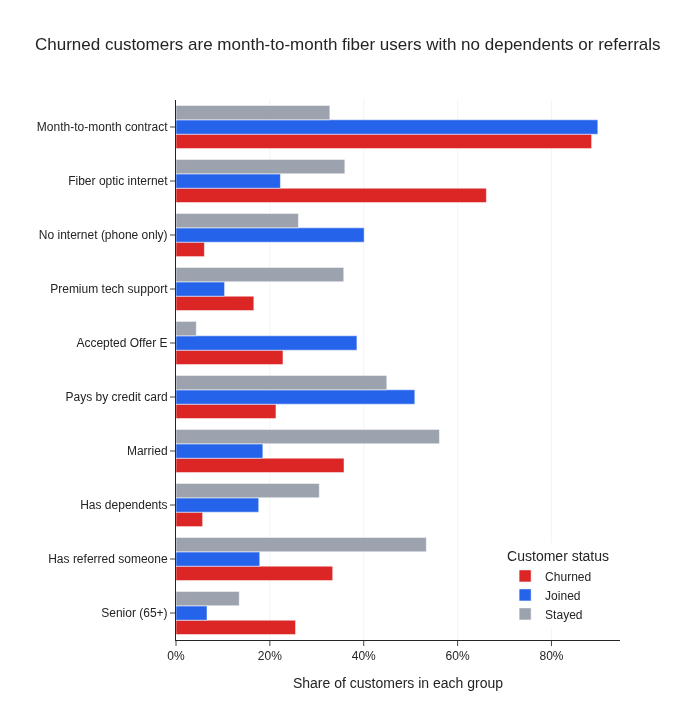

In [17]:
df_plot = df_profile[share_cols].reset_index().melt(
    id_vars='Customer Status',
    var_name='trait',
    value_name='share',
)

fig = px.bar(
    df_plot,
    x='share',
    y='trait',
    color='Customer Status',
    barmode='group',
    orientation='h',
    color_discrete_map={
        'Churned': COLOR_CHURNED,
        'Joined': COLOR_JOINED,
        'Stayed': COLOR_STAYED,
    },
    category_orders={
        'trait': share_cols,
        'Customer Status': ['Churned', 'Joined', 'Stayed'],
    },
    labels={
        'share': 'Share of customers in each group',
        'trait': '',
        'Customer Status': 'Customer status',
    },
    title='Churned customers are month-to-month fiber users with no dependents or referrals',
    height=720,
)

fig.update_xaxes(tickformat='.0%', showgrid=True, gridcolor='#F3F4F6')
fig.update_layout(legend=dict(yanchor='bottom', y=0.02, xanchor='right', x=0.98))

fig.show()

**Churned customers** stand out on almost every dimension:

- **Contract:** 88.6% were on month-to-month contracts, compared with 32.8% of the customers who stayed.
- **Tenure:** a median tenure of 10 months versus 42 months for stayers. Many leave early.
- **Services and price:** 66.1% had fiber optic internet (vs. 36.0% of stayers), and they paid more: a median monthly charge of \$79.50 vs. \$65.60. Only 16.6% had premium tech support (vs. 35.7%).
- **Household and engagement:** only 5.7% had dependents (vs. 30.5%), 33.4% had ever referred someone (vs. 53.3%), and they were older (average age 49.7 vs. 45.6; 25.5% were 65 or older vs. 13.5%).

**Joined customers** look different again. They are younger (average age 42.9) and cheaper (median \$43.98 a month), and 40.1% are phone-only customers with no internet. But 89.9% are on month-to-month contracts and 38.5% came in on Offer E, so on contract terms they resemble the churned group more than the stayed group. They are a natural first target for retention efforts.

**Stayed customers** are the loyal core: long-tenured (median 42 months), mostly on one- or two-year contracts, more often married (56.1%) and with dependents, and more likely to pay by credit card (44.9%).

## Key drivers of churn

From here on, the **churn rate** of a group is the share of its customers who churned during the quarter. We compute it over all 7,043 customers and count Joined customers as not churned (the modeling section explains why this is the right choice). The overall churn rate is 26.5%.

### 👉 Contract type and tenure

In [18]:
df['Tenure Band'] = pd.cut(
    df['Tenure in Months'],
    bins=[0, 3, 6, 12, 24, 48, 72],
    labels=['1-3', '4-6', '7-12', '13-24', '25-48', '49-72'],
)

df.groupby('Contract').agg(
    customers=('Churned', 'size'),
    churn_rate=('Churned', 'mean'),
).round(3)

,customers,churn_rate
Contract,,
Month-to-Month,3610,0.458
One Year,1550,0.107
Two Year,1883,0.025


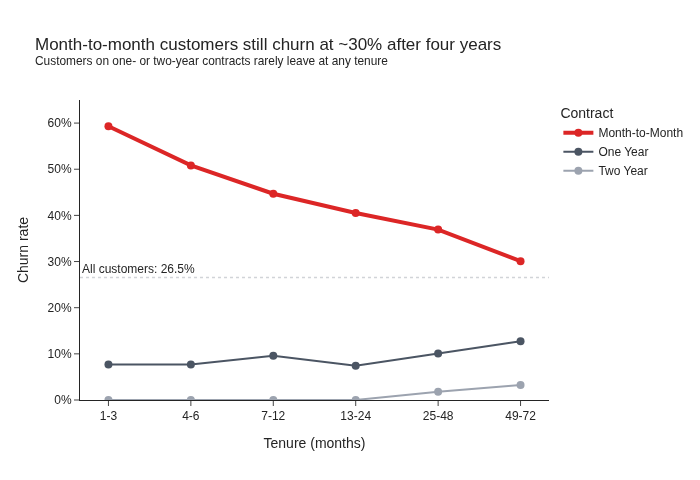

In [19]:
df_tenure_contract = df.groupby(['Contract', 'Tenure Band'], as_index=False, observed=True).agg({
    'Churned': 'mean',
    'Customer ID': 'count',
}).rename(columns={
    'Churned': 'churn_rate',
    'Customer ID': 'customers',
})

fig = px.line(
    df_tenure_contract,
    x='Tenure Band',
    y='churn_rate',
    color='Contract',
    markers=True,
    hover_data={'customers': True},
    color_discrete_map={
        'Month-to-Month': COLOR_CHURNED,
        'One Year': '#4B5563',
        'Two Year': COLOR_STAYED,
    },
    labels={
        'Tenure Band': 'Tenure (months)',
        'churn_rate': 'Churn rate',
        'customers': 'Customers',
    },
    title='Month-to-month customers still churn at ~30% after four years'
          '<br><sup>Customers on one- or two-year contracts rarely leave at any tenure</sup>',
    height=480,
)

fig.update_traces(line_width=2, marker_size=8)
fig.update_traces(selector={'name': 'Month-to-Month'}, line_width=4)
fig.add_hline(
    y=df['Churned'].mean(),
    line_dash='dot',
    line_width=1.5,
    line_color='#6B7280',
    annotation_text=f"All customers: {df['Churned'].mean():.1%}",
    annotation_position='top left',
)
fig.update_yaxes(tickformat='.0%', range=[0, 0.65])

fig.show()

In [20]:
df_tenure_contract.pivot(index='Contract', columns='Tenure Band', values='churn_rate').round(3)

Tenure Band,1-3,4-6,7-12,13-24,25-48,49-72
Contract,,,,,,
Month-to-Month,0.593,0.508,0.447,0.405,0.369,0.301
One Year,0.077,0.077,0.096,0.074,0.101,0.128
Two Year,0.000,0.000,0.000,0.000,0.018,0.032


Contract type is the single strongest driver: **45.8% of month-to-month customers churned, compared with 10.7% on one-year and 2.5% on two-year contracts.**

Tenure matters too, mostly *within* month-to-month customers. Their churn rate falls from 59.3% in the first three months to 30.1% after four years, yet even the longest-tenured month-to-month customers churn more than the average customer (26.5%). Customers on one- or two-year contracts rarely churn at any tenure (12.8% or less). Few customers sign a one- or two-year contract in their first six months, so those early points rest on small groups (hover over the chart for counts).

### 👉 Churn rate across customer attributes

To scan for other drivers, we compute the churn rate for every level of several attributes and compare each with the overall average. A few helper columns group age, dependents, and referrals into bands.

In [21]:
df['Age Group'] = pd.cut(df['Age'], bins=[0, 29, 64, 120], labels=['Under 30', '30-64', '65+'])
df['Has Dependents'] = np.where(df['Number of Dependents'] > 0, 'Yes', 'No')
df['Referrals'] = pd.cut(df['Number of Referrals'], bins=[-1, 0, 1, 11], labels=['0', '1', '2+'])

attributes = [
    'Contract', 'Internet Type', 'Premium Tech Support', 'Online Security', 'Payment Method',
    'Paperless Billing', 'Has Dependents', 'Referrals', 'Married', 'Age Group', 'Gender',
]


def churn_scan(data, attributes):
    """Churn rate and customer count for every level of each attribute."""
    return pd.concat([
        data.groupby(attr, observed=True).agg(
            customers=('Churned', 'size'),
            churn_rate=('Churned', 'mean'),
        ).reset_index(names='level').assign(attribute=attr, level=lambda d: d['level'].astype(str))
        for attr in attributes
    ], ignore_index=True)


df_scan = churn_scan(df, attributes)
df_scan['label'] = df_scan['attribute'] + ': ' + df_scan['level']

df_scan.head()

,level,customers,churn_rate,attribute,label
0,Month-to-Month,3610,0.458449,Contract,Contract: Month-to-Month
1,One Year,1550,0.107097,Contract,Contract: One Year
2,Two Year,1883,0.025491,Contract,Contract: Two Year
3,Cable,830,0.256627,Internet Type,Internet Type: Cable
4,DSL,1652,0.185835,Internet Type,Internet Type: DSL


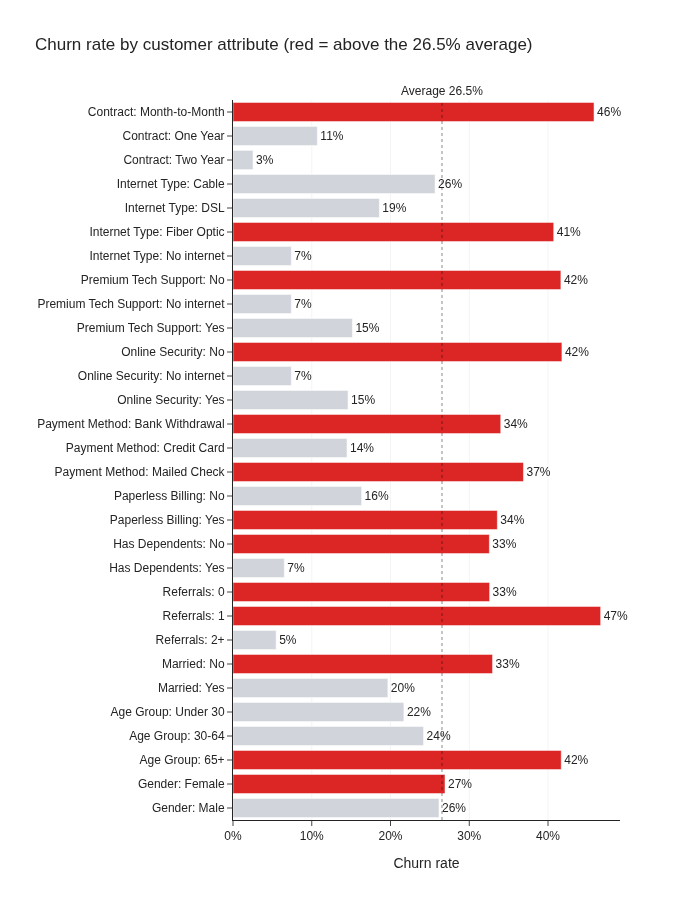

In [22]:
overall_churn_rate = df['Churned'].mean()
df_scan['vs_overall'] = np.where(df_scan['churn_rate'] > overall_churn_rate, 'Above average', 'Below average')

fig = px.bar(
    df_scan,
    x='churn_rate',
    y='label',
    color='vs_overall',
    orientation='h',
    text=df_scan['churn_rate'].map(lambda r: f'{r:.0%}'),
    hover_data={'customers': True, 'vs_overall': False},
    color_discrete_map={
        'Above average': COLOR_CHURNED,
        'Below average': COLOR_LIGHT_GRAY,
    },
    category_orders={'label': df_scan['label'].tolist()},
    labels={
        'churn_rate': 'Churn rate',
        'label': '',
        'vs_overall': '',
        'customers': 'Customers',
    },
    title=f'Churn rate by customer attribute (red = above the {overall_churn_rate:.1%} average)',
    height=900,
)

fig.add_vline(
    x=overall_churn_rate,
    line_dash='dot',
    line_width=1.5,
    line_color='black',
    annotation_text=f'Average {overall_churn_rate:.1%}',
    annotation_position='top',
)
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_xaxes(tickformat='.0%', showgrid=True, gridcolor='#F3F4F6')
fig.update_layout(showlegend=False)

fig.show()

With 7,043 customers, even small gaps can be statistically significant, so we also measure *how strongly* each attribute is associated with churn. A chi-square test checks whether churn depends on the attribute at all, and **Cramér's V** measures the strength of the association on a 0–1 scale (as a rule of thumb, 0.1 is small, 0.3 medium, and 0.5 large).

In [23]:
from scipy.stats import chi2_contingency


def churn_association(attr):
    table = pd.crosstab(df[attr], df['Churned'])
    chi2, p_value, dof, expected = chi2_contingency(table)
    # Cramer's V: 0 = no association, 1 = perfect association
    cramers_v = np.sqrt(chi2 / (table.to_numpy().sum() * (min(table.shape) - 1)))
    return {'attribute': attr, 'p_value': p_value, 'cramers_v': cramers_v}


df_assoc = pd.DataFrame([churn_association(attr) for attr in attributes]) \
    .sort_values('cramers_v', ascending=False) \
    .reset_index(drop=True)

df_assoc['p_value'] = df_assoc['p_value'].map(lambda p: f'{p:.1e}')
df_assoc.round({'cramers_v': 3})

,attribute,p_value,cramers_v
0,Contract,0.0e+00,0.453
1,Online Security,2.7e-185,0.347
2,Premium Tech Support,1.4e-180,0.343
3,Referrals,6.6e-171,0.334
4,Internet Type,2.2e-141,0.305
5,Has Dependents,2.5e-96,0.248
6,Payment Method,4.4e-74,0.219
7,Paperless Billing,4.1e-58,0.191
8,Age Group,2.7e-36,0.152
9,Married,2.1e-36,0.150


Ranked by Cramér's V:

1. **Contract** (V = 0.453) is by far the strongest.
2. **Online security, premium tech support, and referrals** (V between 0.334 and 0.347) come next. Internet customers *without* online security or premium tech support churn at 42%, versus 15% for those who have them. Customers who referred two or more people churned at only 5%. Curiously, customers with exactly one referral churned at 47%, the highest rate of any group in the chart (more on referrals in the model section).
3. **Internet type** (V = 0.305): fiber optic customers churn at 41%, about double the rate of DSL customers (19%), while phone-only customers rarely churn (7%).
4. **Dependents, payment method, paperless billing, age, and marital status** have small-to-medium associations. Customers with dependents churn at 7% versus 33% without; credit card payers at 14% versus 34% for bank withdrawal and 37% for mailed check; seniors (65+) at 42%.
5. **Gender** has no relationship with churn (27% vs. 26%, p = 0.49), a useful sanity check.

These are associations, not causes, and the attributes overlap. For example, fiber customers pay higher monthly charges, and customers who buy add-ons may simply be more engaged to begin with. The prediction model later looks at all of these factors together.

### 👉 Do marketing offers reduce churn? A confounding trap

`Offer` records the last marketing offer each customer accepted. Let's compare churn rates by offer, along with the range of tenures of the customers who received each one.

In [24]:
df.groupby('Offer').agg(
    customers=('Churned', 'size'),
    churn_rate=('Churned', 'mean'),
    min_tenure=('Tenure in Months', 'min'),
    max_tenure=('Tenure in Months', 'max'),
).round(3)

,customers,churn_rate,min_tenure,max_tenure
Offer,,,,
None,3877,0.271,1,72
Offer A,520,0.067,66,72
Offer B,824,0.123,40,65
Offer C,415,0.229,24,39
Offer D,602,0.267,10,23
Offer E,805,0.529,1,10


At first glance, Offer A looks like a retention win (6.7% churn) and Offer E looks like a disaster (52.9%), compared with 27.1% for customers with no offer. But look at the tenure columns: **each offer went only to customers in a specific tenure window**. Offer A went exclusively to customers with 66–72 months of tenure, Offer E only to customers with 1–10 months. Since tenure itself strongly predicts churn, the effect of the offer is tangled up with the effect of tenure. This is **confounding**.

A fairer comparison holds tenure roughly fixed: for each offer, compare its customers with the *no-offer* customers whose tenure falls in the same window.

In [25]:
offer_rows = []

for offer in ['Offer A', 'Offer B', 'Offer C', 'Offer D', 'Offer E']:
    df_offer_customers = df.query('Offer == @offer')
    min_tenure = df_offer_customers['Tenure in Months'].min()
    max_tenure = df_offer_customers['Tenure in Months'].max()

    # customers with no offer whose tenure falls in the same window
    df_no_offer_same_window = df.query('Offer == "None"') \
        .loc[lambda d: d['Tenure in Months'].between(min_tenure, max_tenure)]

    offer_rows.append({
        'Offer': offer,
        'Tenure window (months)': f'{min_tenure}-{max_tenure}',
        'Customers with offer': len(df_offer_customers),
        'Churn rate: with offer': df_offer_customers['Churned'].mean(),
        'Customers with no offer (same window)': len(df_no_offer_same_window),
        'Churn rate: no offer, same tenure window': df_no_offer_same_window['Churned'].mean(),
    })

df_offer = pd.DataFrame(offer_rows)
df_offer['Difference (pct. points)'] = 100 * (
    df_offer['Churn rate: with offer'] - df_offer['Churn rate: no offer, same tenure window'])

df_offer.round(3)

,Offer,Tenure window (months),Customers with offer,Churn rate: with offer,Customers with no offer (same window),"Churn rate: no offer, same tenure window",Difference (pct. points)
0,Offer A,66-72,520,0.067,513,0.055,1.273
1,Offer B,40-65,824,0.123,964,0.158,-3.510
2,Offer C,24-39,415,0.229,691,0.217,1.184
3,Offer D,10-23,602,0.267,668,0.335,-6.789
4,Offer E,1-10,805,0.529,1111,0.472,5.755


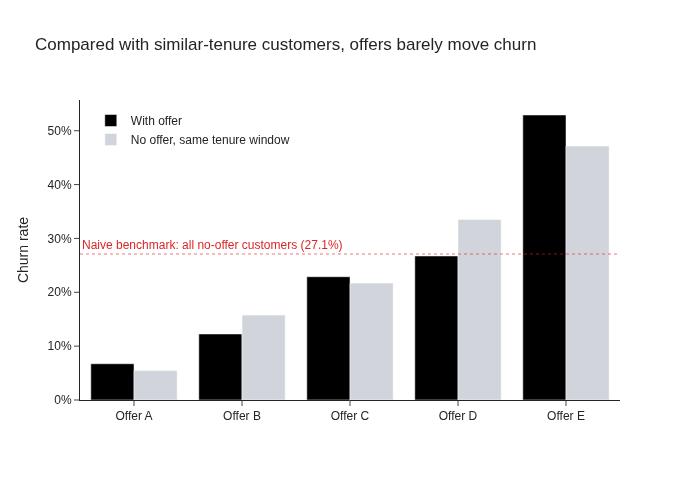

In [26]:
naive_benchmark = df.query('Offer == "None"')['Churned'].mean()

df_plot = df_offer.melt(
    id_vars='Offer',
    value_vars=['Churn rate: with offer', 'Churn rate: no offer, same tenure window'],
    var_name='group',
    value_name='churn_rate',
)
df_plot['group'] = df_plot['group'].str.replace('Churn rate: ', '').str.capitalize()

fig = px.bar(
    df_plot,
    x='Offer',
    y='churn_rate',
    color='group',
    barmode='group',
    color_discrete_map={
        'With offer': 'black',
        'No offer, same tenure window': COLOR_LIGHT_GRAY,
    },
    labels={
        'churn_rate': 'Churn rate',
        'Offer': '',
        'group': '',
    },
    title='Compared with similar-tenure customers, offers barely move churn',
    height=480,
)

fig.add_hline(
    y=naive_benchmark,
    line_dash='dot',
    line_width=2,
    line_color=COLOR_CHURNED,
    annotation_text=f'Naive benchmark: all no-offer customers ({naive_benchmark:.1%})',
    annotation_position='top left',
    annotation_font_color=COLOR_CHURNED,
)
fig.update_yaxes(tickformat='.0%')
fig.update_layout(legend=dict(yanchor='top', y=0.98, xanchor='left', x=0.02))

fig.show()

Once tenure is held roughly constant, the dramatic differences disappear:

- **Offer A** (6.7% vs. 5.5%) and **Offer C** (22.9% vs. 21.7%) show essentially no difference from having no offer.
- **Offer B** (-3.5 percentage points) and **Offer D** (-6.8 points) are associated with modestly lower churn.
- **Offer E**, the offer that new customers receive, is associated with *higher* churn than no offer (52.9% vs. 47.2%, +5.8 points).

The headline numbers mostly reflect *who* received each offer, not what the offer did. Even the matched comparison is not a controlled experiment (customers who accept an offer may differ from those who don't), so the right way to measure an offer's effect is a randomized test. For the client, the practical takeaway is that Offer E, its main offer for new customers, does not appear to buy loyalty.

### 👉 Why do churned customers say they left?

Churned customers were asked for a reason when they left. `Churn Category` groups the 20 specific reasons into five categories.

In [27]:
df_churned = df.query('Churned == 1')

df_churned['Churn Category'].value_counts().to_frame().assign(
    share=lambda d: (d['count'] / d['count'].sum()).round(3)
)

,count,share
Churn Category,,
Competitor,841,0.450
Dissatisfaction,321,0.172
Attitude,314,0.168
Price,211,0.113
Other,182,0.097


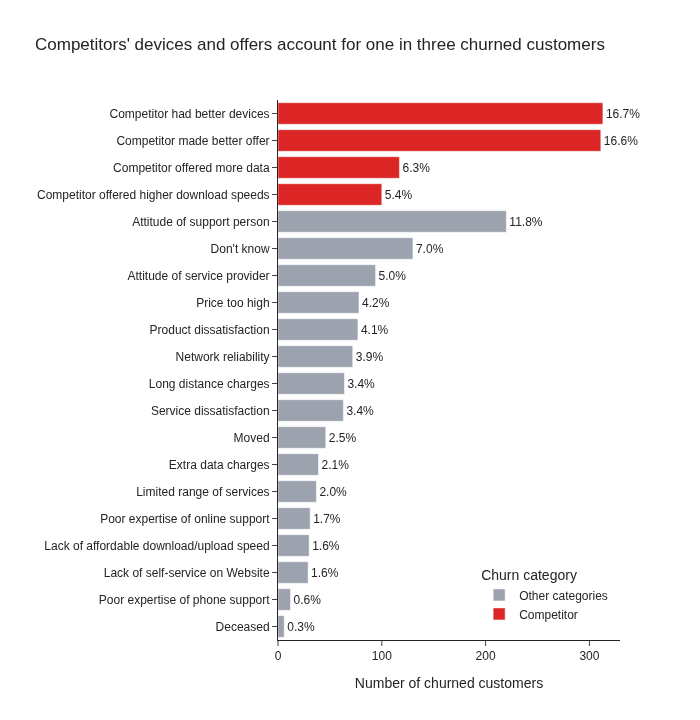

In [28]:
df_reasons = df_churned.groupby(['Churn Category', 'Churn Reason'], as_index=False).agg({
    'Customer ID': 'count',
}).rename(columns={
    'Customer ID': 'churners',
}).sort_values('churners', ascending=True)

df_reasons['share'] = df_reasons['churners'] / df_reasons['churners'].sum()
df_reasons['highlight'] = np.where(df_reasons['Churn Category'] == 'Competitor', 'Competitor', 'Other categories')

fig = px.bar(
    df_reasons,
    x='churners',
    y='Churn Reason',
    color='highlight',
    orientation='h',
    text=df_reasons['share'].map(lambda s: f'{s:.1%}'),
    hover_data={'Churn Category': True, 'highlight': False},
    color_discrete_map={
        'Competitor': COLOR_CHURNED,
        'Other categories': COLOR_STAYED,
    },
    labels={
        'churners': 'Number of churned customers',
        'Churn Reason': '',
        'highlight': 'Churn category',
    },
    title='Competitors\' devices and offers account for one in three churned customers',
    height=720,
)

fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(legend=dict(yanchor='bottom', y=0.02, xanchor='right', x=0.98))

fig.show()

In [29]:
devices_or_offer = df_churned['Churn Reason'].isin(['Competitor had better devices', 'Competitor made better offer'])

print(f'Churned because a competitor had better devices or a better offer: '
      f'{devices_or_offer.sum()} of {len(df_churned):,} ({devices_or_offer.mean():.1%})')

Churned because a competitor had better devices or a better offer: 624 of 1,869 (33.4%)


**Competitors are the main reason customers leave: 45.0% of churned customers named a competitor.** Within that category, two reasons dominate: the competitor *had better devices* (313 customers, 16.7%) or *made a better offer* (311, 16.6%). Together they account for 624 of the 1,869 churned customers (33.4%), one in three. Competitors offering more data (6.3%) or faster download speeds (5.4%) matter much less.

The largest non-competitor reason is the **attitude of a support person** (220 customers, 11.8%), which together with the attitude of the service provider makes up the Attitude category (16.8%). This lines up with the earlier finding that customers with premium tech support churn far less. Price-related reasons (11.3%) matter less than one might expect.

As the next section shows, the "Competitor made better offer" losses are heavily concentrated in one region.

### 👉 Is churn concentrated geographically?

The data includes each customer's zip code and coordinates. Aggregating customers to the zip-code level shows whether churn clusters anywhere.

In [30]:
df_zip = df.groupby(['Zip Code', 'City'], as_index=False).agg({
    'Customer ID': 'count',
    'Churned': 'mean',
    'Latitude': 'mean',
    'Longitude': 'mean',
}).rename(columns={
    'Customer ID': 'customers',
    'Churned': 'churn_rate',
})

df_zip['customers'].describe()

count    1626.000000
mean        4.331488
std         2.159819
min         1.000000
25%         4.000000
50%         4.000000
75%         4.000000
max        43.000000
Name: customers, dtype: float64

In [31]:
# Zip codes with an unusually large number of customers
df_large_zips = df_zip.query('customers >= 15').sort_values('churn_rate', ascending=False)

# Hotspots: large zip codes where a majority of customers churned
hotspot_zips = df_large_zips.query('churn_rate >= 0.5')['Zip Code'].tolist()

print(f'Zip codes with 15+ customers: {len(df_large_zips)}')
print(f'Hotspot zip codes (15+ customers and 50%+ churn): {len(hotspot_zips)}')
df_large_zips[['Zip Code', 'City', 'customers', 'churn_rate']].round(3)

Zip codes with 15+ customers: 10
Hotspot zip codes (15+ customers and 50%+ churn): 9


,Zip Code,City,customers,churn_rate
375,92129,San Diego,16,0.938
369,92122,San Diego,36,0.917
376,92130,San Diego,22,0.909
357,92109,San Diego,27,0.889
364,92117,San Diego,34,0.882
372,92126,San Diego,32,0.875
368,92121,San Diego,20,0.850
324,92028,Fallbrook,43,0.605
520,92592,Temecula,30,0.600
323,92027,Escondido,38,0.395


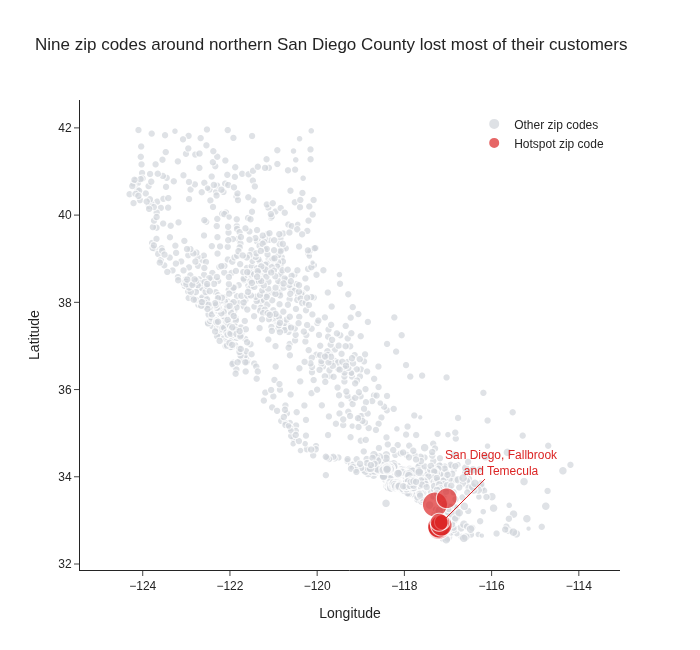

In [32]:
df_zip['group'] = np.where(df_zip['Zip Code'].isin(hotspot_zips), 'Hotspot zip code', 'Other zip codes')

fig = px.scatter(
    df_zip.sort_values('group', ascending=False),
    x='Longitude',
    y='Latitude',
    size='customers',
    color='group',
    hover_data={'City': True, 'Zip Code': True, 'customers': True, 'churn_rate': ':.0%', 'group': False},
    color_discrete_map={
        'Hotspot zip code': COLOR_CHURNED,
        'Other zip codes': COLOR_LIGHT_GRAY,
    },
    labels={
        'group': '',
        'customers': 'Customers',
        'churn_rate': 'Churn rate',
    },
    title='Nine zip codes around northern San Diego County lost most of their customers',
    height=650,
    size_max=25,
)

fig.update_yaxes(scaleanchor='x', scaleratio=1)
fig.add_annotation(
    x=-117.15, y=32.95,
    ax=60, ay=-60,
    text='San Diego, Fallbrook<br>and Temecula',
    showarrow=True,
    arrowcolor=COLOR_CHURNED,
    font_color=COLOR_CHURNED,
)
fig.update_layout(legend=dict(yanchor='top', y=0.98, xanchor='right', x=0.98))

fig.show()

In [33]:
df['Hotspot Zip'] = df['Zip Code'].isin(hotspot_zips)

df.groupby('Hotspot Zip').agg(
    customers=('Churned', 'size'),
    churners=('Churned', 'sum'),
    churn_rate=('Churned', 'mean'),
    churned_for_better_competitor_offer=('Churn Reason', lambda s: (s == 'Competitor made better offer').sum()),
).round(3)

,customers,churners,churn_rate,churned_for_better_competitor_offer
Hotspot Zip,,,,
False,6783,1658,0.244,125
True,260,211,0.812,186


Most zip codes contain only about four customers, so zip-level churn rates are usually noisy. But the 10 zip codes with 15 or more customers stand out: **9 of them are churn hotspots**, seven in San Diego where 85–94% of customers churned, plus nearby Fallbrook (60.5%) and Temecula (60.0%), all in or next to northern San Diego County. The 10th, Escondido (39.5%), is also in San Diego County and also churned well above average.

- The 260 customers in the 9 hotspot zip codes churned at **81.2%**, versus 24.4% everywhere else.
- They account for **186 of the 311 "Competitor made better offer" churns**, about 60% of that reason on less than 4% of the customer base.

This looks like a **local competitor campaign** (for example, a regional rival running an aggressive promotion) rather than a company-wide problem. The data can't confirm that hypothesis, but it suggests a targeted response, such as matching the offer locally, rather than a blanket discount.

**Does city size matter?** The second file, `telecom_zipcode_population.csv`, gives the population of each zip code. Joining it to the customer table lets us check whether customers in more populous zip codes churn more.

In [34]:
df_zip_population = pd.read_csv('telecom_zipcode_population.csv')

df = df.merge(df_zip_population, on='Zip Code', how='left', validate='many_to_one')
print(f"Customers without a population match: {df['Population'].isna().sum()}")

df['Zip Population Quintile'] = pd.qcut(
    df['Population'], 5,
    labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4', 'Q5 (largest)'],
)

pd.concat({
    'churn_rate_all_zips': df.groupby('Zip Population Quintile', observed=True)['Churned'].mean(),
    'churn_rate_excluding_hotspots': df[~df['Hotspot Zip']].groupby('Zip Population Quintile', observed=True)['Churned'].mean(),
}, axis=1).round(3)

Customers without a population match: 0


,churn_rate_all_zips,churn_rate_excluding_hotspots
Zip Population Quintile,,
Q1 (smallest),0.240,0.240
Q2,0.246,0.238
Q3,0.240,0.240
Q4,0.287,0.260
Q5 (largest),0.313,0.245


At first, churn seems to rise with zip-code population: 24.0% in the smallest quintile vs. 31.3% in the largest. But once the hotspot zip codes are excluded, the gap largely disappears (24.0% vs. 24.5%). **City size by itself is not a churn driver**; the apparent effect came from a few populous zip codes in and around San Diego.

## Is the company losing high-value customers?

How we define "value" matters. A customer's **lifetime revenue** (`Total Revenue`) mostly reflects how long they have been a customer, and churned customers stop accumulating it when they leave. A better measure of what the company loses when a customer leaves is the **monthly charge**: the revenue that customer would have kept paying. We split customers into quartiles by monthly charge and call the top quartile **high-value customers**.

In [35]:
df['Monthly Charge Quartile'] = pd.qcut(
    df['Monthly Charge'], 4,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'],
)

df_value = df.groupby('Monthly Charge Quartile', as_index=False, observed=True).agg(
    min_charge=('Monthly Charge', 'min'),
    max_charge=('Monthly Charge', 'max'),
    customers=('Churned', 'size'),
    churners=('Churned', 'sum'),
    churn_rate=('Churned', 'mean'),
)

df_lost = df.query('Churned == 1').groupby('Monthly Charge Quartile', as_index=False, observed=True).agg(
    monthly_charges_lost=('Monthly Charge', 'sum'),
)

df_value = df_value.merge(df_lost, on='Monthly Charge Quartile')
df_value['share_of_charges_lost'] = df_value['monthly_charges_lost'] / df_value['monthly_charges_lost'].sum()

df_value.round(3)

,Monthly Charge Quartile,min_charge,max_charge,customers,churners,churn_rate,monthly_charges_lost,share_of_charges_lost
0,Q1 (lowest),-10.00,30.40,1762,192,0.109,3477.05,0.025
1,Q2,30.45,70.05,1765,429,0.243,22686.15,0.165
2,Q3,70.10,89.75,1762,669,0.380,53362.75,0.389
3,Q4 (highest),89.80,118.75,1754,579,0.330,57560.70,0.420


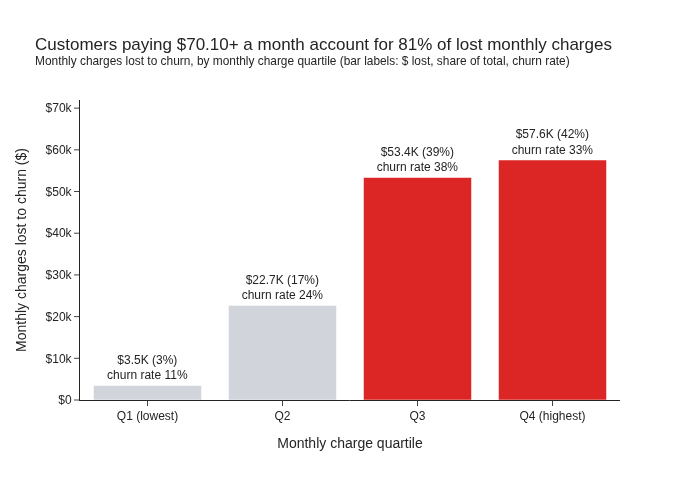

In [36]:
fig = px.bar(
    df_value,
    x='Monthly Charge Quartile',
    y='monthly_charges_lost',
    color='Monthly Charge Quartile',
    text=df_value.apply(
        lambda r: f"${r['monthly_charges_lost'] / 1000:,.1f}K ({r['share_of_charges_lost']:.0%})<br>"
                  f"churn rate {r['churn_rate']:.0%}",
        axis=1,
    ),
    color_discrete_map={
        'Q1 (lowest)': COLOR_LIGHT_GRAY,
        'Q2': COLOR_LIGHT_GRAY,
        'Q3': COLOR_CHURNED,
        'Q4 (highest)': COLOR_CHURNED,
    },
    labels={
        'Monthly Charge Quartile': 'Monthly charge quartile',
        'monthly_charges_lost': 'Monthly charges lost to churn ($)',
    },
    title=f"Customers paying ${df_value['min_charge'].iloc[2]:.2f}+ a month account for "
          f"{df_value['share_of_charges_lost'].iloc[2:].sum():.0%} of lost monthly charges"
          f"<br><sup>Monthly charges lost to churn, by monthly charge quartile (bar labels: $ lost, share of total, churn rate)</sup>",
    height=480,
)

fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_yaxes(tickprefix='$', range=[0, df_value['monthly_charges_lost'].max() * 1.25])
fig.update_layout(showlegend=False)

fig.show()

**Yes, the company is losing high-value customers.** Churn *rises* with monthly charge: 10.9% of the lowest quartile churned, compared with 38.0% in the third quartile and 33.0% in the top quartile (customers paying \$89.80 or more a month). The top quartile alone accounts for \$57.6K (42.0%) of the monthly charges lost to churn, and the top two quartiles together account for 81%.

For contrast, here is what we would have concluded using lifetime revenue instead:

In [37]:
df['Total Revenue Quartile'] = pd.qcut(
    df['Total Revenue'], 4,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'],
)

df.groupby('Total Revenue Quartile', observed=True).agg(
    churn_rate=('Churned', 'mean'),
    median_tenure=('Tenure in Months', 'median'),
).round(3)

,churn_rate,median_tenure
Total Revenue Quartile,,
Q1 (lowest),0.456,3.0
Q2,0.270,17.0
Q3,0.187,40.0
Q4 (highest),0.148,63.0


By lifetime revenue, the "top" customers look safe (14.8% churn) and the bottom quartile looks like the problem (45.6%). But that is mostly a tenure effect: the median tenure is 3 months in the lowest lifetime-revenue quartile and 63 months in the highest. Lifetime revenue answers "who has paid us the most so far?", not "whose departure hurts most going forward?"

### 👉 What separates high-value churners from high-value stayers?

In [38]:
df_high_value = df[df['Monthly Charge Quartile'] == 'Q4 (highest)']

print(f"High-value customers: {len(df_high_value):,} (monthly charge ${df_high_value['Monthly Charge'].min():.2f} or more)")
print(f"Fiber optic share: {(df_high_value['Internet Type'] == 'Fiber Optic').mean():.1%}")

df_high_value.assign(
    month_to_month=df_high_value['Contract'] == 'Month-to-Month',
    premium_tech_support=df_high_value['Premium Tech Support'] == 'Yes',
    online_security=df_high_value['Online Security'] == 'Yes',
    has_dependents=df_high_value['Number of Dependents'] > 0,
).groupby('Customer Status').agg({
    'Customer ID': 'count',
    'Monthly Charge': 'mean',
    'Tenure in Months': 'median',
    'Number of Referrals': 'mean',
    'month_to_month': 'mean',
    'premium_tech_support': 'mean',
    'online_security': 'mean',
    'has_dependents': 'mean',
}).rename(columns={'Customer ID': 'customers'}).T.round(3)

High-value customers: 1,754 (monthly charge $89.80 or more)
Fiber optic share: 95.2%


Customer Status,Churned,Joined,Stayed
customers,579.000,19.000,1156.000
Monthly Charge,99.414,94.542,101.570
Tenure in Months,26.000,3.000,58.000
Number of Referrals,0.737,1.947,3.026
month_to_month,0.786,0.895,0.268
premium_tech_support,0.263,0.158,0.528
online_security,0.228,0.316,0.482
has_dependents,0.031,0.158,0.272


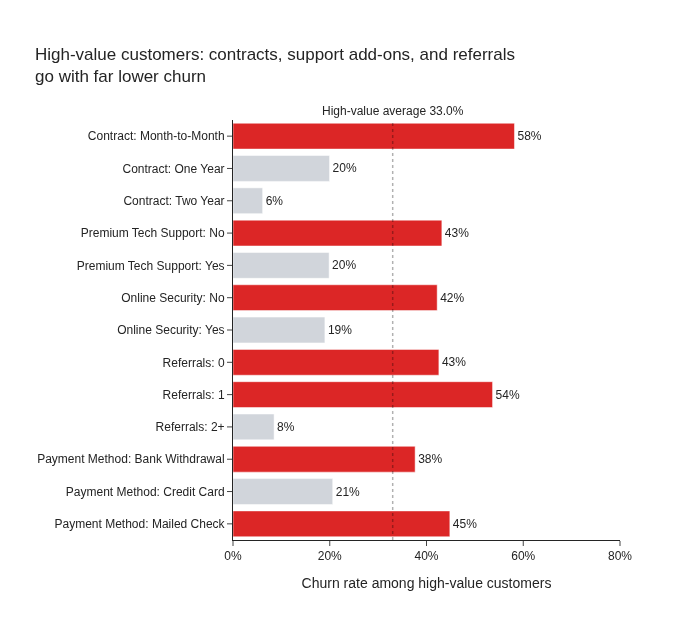

In [39]:
df_hv_scan = churn_scan(df_high_value, ['Contract', 'Premium Tech Support', 'Online Security', 'Referrals', 'Payment Method'])
df_hv_scan['label'] = df_hv_scan['attribute'] + ': ' + df_hv_scan['level']
high_value_churn_rate = df_high_value['Churned'].mean()

fig = px.bar(
    df_hv_scan,
    x='churn_rate',
    y='label',
    orientation='h',
    text=df_hv_scan['churn_rate'].map(lambda r: f'{r:.0%}'),
    hover_data={'customers': True},
    category_orders={'label': df_hv_scan['label'].tolist()},
    labels={
        'churn_rate': 'Churn rate among high-value customers',
        'label': '',
        'customers': 'Customers',
    },
    title='High-value customers: contracts, support add-ons, and referrals<br>go with far lower churn',
    height=620,
)

fig.update_traces(
    marker_color=np.where(df_hv_scan['churn_rate'] > high_value_churn_rate, COLOR_CHURNED, COLOR_LIGHT_GRAY),
    textposition='outside',
    cliponaxis=False,
)
fig.add_vline(
    x=high_value_churn_rate,
    line_dash='dot',
    line_width=1.5,
    line_color='black',
    annotation_text=f'High-value average {high_value_churn_rate:.1%}',
    annotation_position='top',
)
fig.update_xaxes(tickformat='.0%', range=[0, 0.8])
fig.update_layout(margin=dict(t=120))

fig.show()

In [40]:
df_high_value.query('Churned == 1')['Churn Category'].value_counts(normalize=True).round(3)

Churn Category
Competitor         0.470
Dissatisfaction    0.157
Attitude           0.154
Price              0.119
Other              0.100
Name: proportion, dtype: float64

High-value customers are almost all fiber optic subscribers (95.2%). Within this group, churners and stayers differ in the same ways as in the overall customer base, only more sharply:

- **Contract:** 58% of high-value month-to-month customers churned, versus 20% on one-year and 6% on two-year contracts. 78.6% of high-value churners were on month-to-month contracts.
- **Support add-ons:** high-value customers with premium tech support or online security churned at 19–20%, versus 42–43% without them. Only 26.3% of high-value churners had premium tech support, compared with 52.8% of high-value stayers.
- **Referrals and household:** high-value customers who referred two or more people churned at 8%. High-value churners averaged 0.74 referrals versus 3.03 for stayers, and only 3.1% had dependents (vs. 27.2%).
- **Payment:** credit card payers churned at 21%, versus 38% for bank withdrawal and 45% for mailed check.
- **Why they left:** 47.0% cited a competitor, about the same share as among all churners.

**How could the company retain them?** The data points to a few levers. Each should be tested (for example, with a randomized pilot) before a full rollout, because the associations above do not prove causation:

1. **Move month-to-month high-value customers onto one- or two-year contracts**, for example by offering a device upgrade or a price lock in exchange for a term commitment. This addresses both the strongest churn driver and the top competitor reason (better devices).
2. **Bundle premium tech support and online security into high-tier fiber plans** instead of selling them as add-ons. Better support also targets the "attitude of support person" complaints.
3. **Invest in the referral program.** Customers who referred two or more people almost never churn. Referrals may reflect satisfaction rather than cause it, but referral incentives are cheap to test.
4. **Respond to competitor offers locally**, starting with the San Diego hotspot, where a rival's offer appears to have pulled away most customers.

## Can we predict which customers will churn?

The client wants a model that flags customers who are likely to churn, so the retention team can reach out before they leave. We build two classifiers with scikit-learn: a **logistic regression** baseline, which is easy to interpret, and a **gradient boosting** model, a tree ensemble that can capture non-linear patterns and interactions.

### Step 1: Define the target, and avoid a leakage trap

A natural first idea is to model *Churned vs. Stayed* and drop the Joined customers. But recall how the statuses are defined:

In [41]:
pd.crosstab(
    df['Tenure in Months'] <= 3,
    df['Customer Status'],
).rename_axis(index='Tenure of 3 months or less')

Customer Status,Churned,Joined,Stayed
Tenure of 3 months or less,,,
False,1272,0,4720
True,597,454,0


Every customer with 3 months or less of tenure is either Churned (597) or Joined (454); none are labelled Stayed. If we dropped the Joined customers, **every remaining customer with a tenure of 3 months or less would be a churner**, and the model would learn the rule "tenure of 3 months or less means churn" with perfect accuracy. That rule is an artifact of how the labels were assigned, not a real pattern. It would inflate the model's apparent accuracy and wildly overstate the risk for the company's newest customers.

Instead, we define the target as **churned during the quarter (1) vs. still a customer at the end of the quarter (0)**, keeping Joined customers as 0. This matches how the model will be used: to score everyone currently on the books, including new customers. Among customers with 3 months or less of tenure, the churn rate is then 597 / (597 + 454) = 57%, a realistic picture of early churn.

### Step 2: Choose features without leaking the answer

We **exclude** columns that would leak the outcome or that would not help the model generalize:

- `Customer Status`, `Churn Category`, `Churn Reason`: these *are* the outcome, or are only recorded after a customer leaves.
- `Total Charges`, `Total Refunds`, `Total Extra Data Charges`, `Total Long Distance Charges`, `Total Revenue`: cumulative totals that are roughly tenure × monthly charge. They add little beyond `Tenure in Months` and `Monthly Charge`, and for churned customers they stop accumulating at the churn date, which can leak the outcome.
- `Customer ID`, `City`, `Zip Code`, `Latitude`, `Longitude`: an identifier and very granular geography. A model could memorize the San Diego hotspot from the coordinates, but that looks like a one-time local event, not a pattern to expect elsewhere or next quarter.
- `Internet Service`: redundant with `Internet Type`, which has a "No internet" level.

That leaves 24 features. We hold out 25% of customers as a test set, stratified so both sets have the same churn rate.

In [42]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, precision_score, recall_score
from sklearn.inspection import permutation_importance

In [43]:
numeric_features = [
    'Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Monthly Charge',
    'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
]

categorical_features = [
    'Gender', 'Married', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Type',
    *internet_addons, 'Contract', 'Paperless Billing', 'Payment Method',
]

X = df[numeric_features + categorical_features]
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42,
)

print(f'Training set: {X_train.shape[0]:,} customers, churn rate {y_train.mean():.1%}')
print(f'Test set:     {X_test.shape[0]:,} customers, churn rate {y_test.mean():.1%}')
print(f'Features:     {len(numeric_features)} numeric + {len(categorical_features)} categorical')

Training set: 5,282 customers, churn rate 26.5%
Test set:     1,761 customers, churn rate 26.5%
Features:     7 numeric + 17 categorical


### Step 3: Fit a logistic regression baseline and a gradient boosting model

Both models use the same preprocessing: numeric features are standardized and categorical features are one-hot encoded, all inside a scikit-learn `Pipeline` so that cross-validation never leaks test information into preprocessing. We report the **ROC AUC**, the probability that the model ranks a randomly chosen churner above a randomly chosen non-churner (0.5 = random guessing, 1.0 = perfect), from 5-fold cross-validation on the training set and once on the held-out test set.

In [44]:
def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), categorical_features),
    ])


models = {
    'Logistic regression': Pipeline([
        ('preprocess', make_preprocessor()),
        ('model', LogisticRegression(max_iter=1000)),
    ]),
    'Gradient boosting': Pipeline([
        ('preprocess', make_preprocessor()),
        ('model', GradientBoostingClassifier(random_state=42)),
    ]),
}

results = []
test_probs = {}

for name, pipeline in models.items():
    cv_auc = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    pipeline.fit(X_train, y_train)
    test_probs[name] = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        'model': name,
        'cv_roc_auc_mean': cv_auc.mean(),
        'cv_roc_auc_std': cv_auc.std(),
        'test_roc_auc': roc_auc_score(y_test, test_probs[name]),
    })

pd.DataFrame(results).round(3)

,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc
0,Logistic regression,0.898,0.007,0.891
1,Gradient boosting,0.912,0.007,0.907


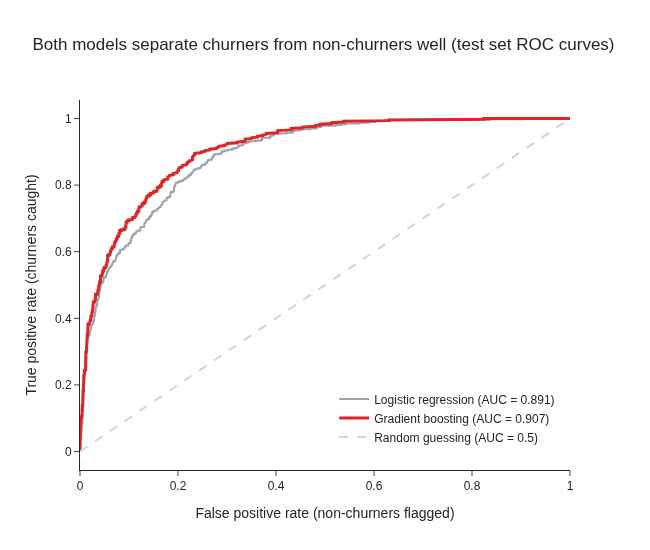

In [45]:
fig = go.Figure()

for name, color, width in [('Logistic regression', COLOR_STAYED, 2), ('Gradient boosting', COLOR_CHURNED, 3)]:
    fpr, tpr, _ = roc_curve(y_test, test_probs[name])
    fig.add_trace(go.Scatter(
        x=fpr,
        y=tpr,
        mode='lines',
        name=f'{name} (AUC = {roc_auc_score(y_test, test_probs[name]):.3f})',
        line=dict(color=color, width=width),
    ))

fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Random guessing (AUC = 0.5)',
    line=dict(color=COLOR_LIGHT_GRAY, dash='dash'),
))

fig.update_layout(
    title='Both models separate churners from non-churners well (test set ROC curves)',
    xaxis_title='False positive rate (non-churners flagged)',
    yaxis_title='True positive rate (churners caught)',
    legend=dict(yanchor='bottom', y=0.05, xanchor='right', x=0.98),
    height=550,
    width=650,
)

fig.show()

Both models perform well. Gradient boosting reaches a **test ROC AUC of 0.907** (0.912 in cross-validation) versus 0.891 for logistic regression (0.898 in cross-validation). The cross-validation and test scores are close, so neither model is badly overfitting. The gain from the more complex model is real but modest; logistic regression is a strong, explainable baseline.

### Step 4: Pick a decision threshold

The model outputs a churn probability, and the business has to decide above which probability to act. A lower threshold catches more churners (higher **recall**) at the cost of contacting more customers who would have stayed anyway (lower **precision**).

In [46]:
churn_prob = test_probs['Gradient boosting']

threshold_rows = []
for threshold in [0.3, 0.4, 0.5, 0.6]:
    predicted = (churn_prob >= threshold).astype(int)
    threshold_rows.append({
        'threshold': threshold,
        'customers_flagged': predicted.sum(),
        'precision': precision_score(y_test, predicted),
        'recall': recall_score(y_test, predicted),
    })

pd.DataFrame(threshold_rows).round(3)

,threshold,customers_flagged,precision,recall
0,0.3,620,0.621,0.824
1,0.4,521,0.672,0.749
2,0.5,437,0.723,0.677
3,0.6,348,0.790,0.589


In [47]:
threshold = 0.4
predicted = (churn_prob >= threshold).astype(int)

pd.DataFrame(
    confusion_matrix(y_test, predicted),
    index=['Actual: did not churn', 'Actual: churned'],
    columns=['Predicted: will not churn', 'Predicted: will churn'],
)

,Predicted: will not churn,Predicted: will churn
Actual: did not churn,1123,171
Actual: churned,117,350


In [48]:
# If the retention team can only call the riskiest 20% of customers, how many churners would they reach?
top_20_pct = pd.Series(churn_prob, index=y_test.index).nlargest(int(len(y_test) * 0.2)).index

print(f'Riskiest 20% of test customers: {len(top_20_pct)}')
print(f'Churners among them: {y_test.loc[top_20_pct].sum()} ({y_test.loc[top_20_pct].mean():.1%} precision)')
print(f'Share of all test-set churners reached: {y_test.loc[top_20_pct].sum() / y_test.sum():.1%}')

Riskiest 20% of test customers: 352
Churners among them: 276 (78.4% precision)
Share of all test-set churners reached: 59.1%


A retention call or discount is usually much cheaper than losing a customer, so we favor recall and use a **threshold of 0.4** rather than the default 0.5. On the 1,761 test customers, the gradient boosting model:

- flags 521 customers, of whom 350 actually churned (precision 67.2%);
- catches 350 of the 467 churners (recall 74.9%);
- misses 117 churners and raises 171 false alarms.

If the retention team can only contact a fixed number of customers, ranking by predicted risk works well: the riskiest 20% of test customers (352) contain 59.1% of all churners, and 78.4% of them actually churned, about three times the 26.5% base rate.

### Step 5: What drives the predictions?

For the gradient boosting model we use **permutation importance**: shuffle one feature at a time in the test set and measure how much the ROC AUC drops. For the logistic regression we look at the coefficients. Because numeric features are standardized, a numeric coefficient is the change in the log-odds of churning for a one-standard-deviation increase; `odds_multiplier` expresses the same effect as a multiplier on the odds.

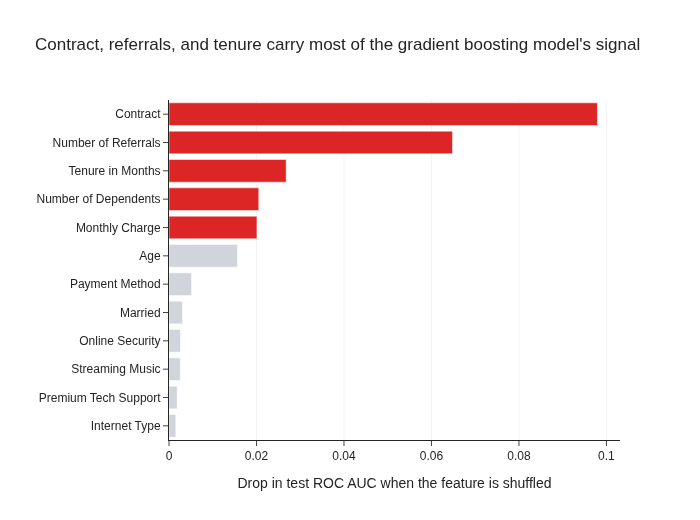

In [49]:
perm = permutation_importance(
    models['Gradient boosting'], X_test, y_test,
    scoring='roc_auc', n_repeats=10, random_state=42,
)

df_importance = pd.DataFrame({
    'feature': X_test.columns,
    'auc_drop': perm.importances_mean,
}).sort_values('auc_drop', ascending=False).reset_index(drop=True)

df_plot = df_importance.head(12).sort_values('auc_drop')

fig = px.bar(
    df_plot,
    x='auc_drop',
    y='feature',
    orientation='h',
    labels={
        'auc_drop': 'Drop in test ROC AUC when the feature is shuffled',
        'feature': '',
    },
    title='Contract, referrals, and tenure carry most of the gradient boosting model\'s signal',
    height=520,
)

fig.update_traces(marker_color=np.where(df_plot['auc_drop'] >= df_importance['auc_drop'].iloc[4], COLOR_CHURNED, COLOR_LIGHT_GRAY))
fig.update_xaxes(showgrid=True, gridcolor='#F3F4F6')

fig.show()

In [50]:
df_importance.head(8).round(3)

,feature,auc_drop
0,Contract,0.098
1,Number of Referrals,0.065
2,Tenure in Months,0.027
3,Number of Dependents,0.021
4,Monthly Charge,0.020
5,Age,0.016
6,Payment Method,0.005
7,Married,0.003


In [51]:
logit = models['Logistic regression']

df_coef = pd.DataFrame({
    'feature': logit.named_steps['preprocess'].get_feature_names_out(),
    'coefficient': logit.named_steps['model'].coef_[0],
})
df_coef['feature'] = df_coef['feature'].str.replace(r'^(num|cat)__', '', regex=True)
df_coef['odds_multiplier'] = np.exp(df_coef['coefficient'])

df_coef = df_coef.sort_values('coefficient')
pd.concat([df_coef.head(8), df_coef.tail(8)]).round(2)

,feature,coefficient,odds_multiplier
2,Number of Referrals,-1.64,0.19
49,Contract_Two Year,-1.48,0.23
3,Tenure in Months,-0.73,0.48
52,Payment Method_Credit Card,-0.64,0.53
1,Number of Dependents,-0.60,0.55
13,Offer_Offer D,-0.57,0.57
12,Offer_Offer C,-0.52,0.59
34,Premium Tech Support_Yes,-0.42,0.66
14,Offer_Offer E,0.17,1.19
53,Payment Method_Mailed Check,0.26,1.30


In [52]:
# Why does "Married = Yes" get a positive (churn-increasing) coefficient?
# In this dataset, referrals are only ever recorded for married customers.
pd.crosstab(df['Married'], df['Number of Referrals'] > 0).rename_axis(columns='Has referred someone')

Has referred someone,False,True
Married,,
No,3641,0
Yes,180,3222


Both models agree on the main drivers, which match the earlier analysis:

- **Contract** is the most important feature for gradient boosting: shuffling it drops the test AUC by 0.098. In the logistic regression, a month-to-month contract multiplies the odds of churning by about 3 (3.01), while a two-year contract cuts them to about a quarter (0.23).
- **Number of referrals, tenure, number of dependents, and monthly charge** follow. More referrals, longer tenure, and more dependents lower churn risk; a higher monthly charge raises it.
- **Online security, premium tech support, and internet type** rank low in permutation importance despite their strong one-at-a-time associations. They overlap with other features (fiber customers, for example, have higher monthly charges), so shuffling one of them loses little information. Low permutation importance does not mean "irrelevant".

**A caveat on reading coefficients:** the logistic regression gives `Married = Yes` a large *positive* coefficient (odds × 4.86), even though married customers churn less overall (20% vs. 33%). The crosstab explains why: in this dataset, *only* married customers have referrals (3,222 of the married customers have referred someone; no unmarried customer has). The model uses `Married` and `Number of Referrals` together, so their coefficients can't be read in isolation. Similarly, `Offer A` gets a positive coefficient because offers are tied to tenure windows that the model already accounts for. With correlated features, read coefficients as a group, not one at a time.

**Model limitations:** the model is trained on a single quarter of simulated data, and tenure for churned customers is measured at the time they left rather than at the end of the quarter. Before using it to target customers, the client should validate it on a later quarter.

## Key Findings

- **The customer base shrank by 21.5% in one quarter.** 1,869 customers churned and only 454 joined (4.1 churned per new customer). Departing customers took \$137,087 in monthly charges (32.0% of the starting total), while new customers added \$19,420.
- **Contract type is the dominant driver.** 45.8% of month-to-month customers churned versus 10.7% (one-year) and 2.5% (two-year), and month-to-month customers still churned at 30.1% after more than four years of tenure.
- **Support add-ons, referrals, and dependents go with much lower churn.** Internet customers with online security or premium tech support churned at 15% vs. 42% without; customers with 2+ referrals churned at 5%, and those with dependents at 7%.
- **Offers are a confounding trap.** Offer A (6.7% churn) and Offer E (52.9%) look like a success and a failure, but each offer targets a narrow tenure window. At matched tenure, offers shift churn by only -6.8 to +5.8 points, and Offer E is associated with *higher* churn.
- **Competitors drive 45.0% of churn**, mostly through better devices (313 customers) and better offers (311). The "better offer" losses are concentrated in 9 zip codes in and around northern San Diego County, where 81.2% of customers churned (186 of the 311 such churns).
- **The company is losing high-value customers.** Churn rises with monthly charge (10.9% in the lowest quartile vs. 33.0% in the top quartile), and the top two quartiles account for 81% of lost monthly charges. Judging value by lifetime revenue would wrongly suggest the opposite.
- **Churn is predictable.** A gradient boosting model reaches a test ROC AUC of 0.907 (logistic regression: 0.891). At a 0.4 threshold it catches 74.9% of churners with 67.2% precision, and the riskiest 20% of customers contain 59.1% of all churners.

## Case Study Potential

**Verdict: Strong.** The data is clean, intuitive (everyone understands a phone and internet bill), and rich enough to support a full analytics arc, from descriptive profiling to a predictive model. More importantly, it contains several genuine "gotchas" that make excellent teaching moments: a label definition that silently leaks the target (Joined vs. Stayed), a classic confounder (offers tied to tenure), a definition-of-value trap (lifetime vs. monthly revenue), and a hidden geographic hotspot that explains an apparent city-size effect.

**Suggested framing:** You are an analyst at a California telecom provider that just lost a fifth of its customers in one quarter. The VP of Customer Retention has a fixed budget for retention offers next quarter and needs to know (1) why customers are leaving, (2) which customers are worth saving, and (3) which current customers to contact first. Students deliver a diagnosis, a recommended set of retention levers, and a churn model with a justified decision threshold.

**Analytics skills exercised:** data cleaning (structural missing values, negative charges), `groupby` aggregation and rate comparisons, chi-square tests and effect sizes (Cramér's V), confounding and stratified comparisons, joins (zip-code population), geographic aggregation, and classification with scikit-learn (pipelines, one-hot encoding, cross-validation, ROC AUC, thresholds, permutation importance), plus translating model output into a business decision.

**Candidate student questions:**

1. Why is it a mistake to train a Churned-vs-Stayed model without the Joined customers? What happens to the model's apparent accuracy if you do?
2. Offer A customers churn at 6.7% and Offer E customers at 52.9%. Should the company give Offer A to everyone? Design a fair comparison, or an experiment, to find out.
3. Define "high-value customer" in two different ways. How does the answer to "Are we losing high-value customers?" change?
4. Churn appears to rise with zip-code population. Is city size a real driver? What explains the pattern?
5. Suppose a retention call costs \$20 and saves a would-be churner 30% of the time. Which threshold maximizes the expected profit of your model?

**Data limitations:** this is a simulated teaching dataset (its 7,043 customers match the size of IBM's sample Telco churn data, which it appears to extend), and some patterns are clearly artificial: a 28.4% quarterly churn rate, referrals recorded only for married customers, a 47% churn rate for customers with exactly one referral, and most zip codes holding exactly four customers. It covers a single quarter (no time series), churn reasons are self-reported with one reason per customer, tenure for churned customers is measured at departure, and 120 customers have negative monthly charges.